# Batch Document Extraction with Llama Vision (Clean Version)

Streamlined batch processing notebook using modular components.

**Features:**
- Early model loading
- Configurable output directory
- Comprehensive analytics and visualizations
- Clean, modular code structure

## 1. Setup and Configuration

In [1]:
# Core imports
import os
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display
from rich import print as rprint
from rich.console import Console
from rich.table import Table

warnings.filterwarnings('ignore')
console = Console()

# Import batch processing modules
from common.batch_analytics import BatchAnalytics
from common.batch_processor import BatchDocumentProcessor
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images
from common.ground_truth_evaluator import GroundTruthEvaluator

rprint("[bold green]✅ Modules imported successfully[/bold green]")

✅ Modules imported successfully

In [2]:
# Configuration
CONFIG = {
    # Model settings
    'MODEL_PATH': "/home/jovyan/nfs_share/models/Llama-3.2-11B-Vision-Instruct",
    
    # Batch settings
    'DATA_DIR': 'evaluation_data',
    'GROUND_TRUTH': 'evaluation_data/ground_truth.csv',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']
    
    # Output settings
    'OUTPUT_BASE': os.getenv('OUTPUT_DIR', 'output'),
    
    # V100 optimization
    'USE_QUANTIZATION': True,
    'DEVICE_MAP': 'auto',
    'MAX_NEW_TOKENS': 4000,
    'TORCH_DTYPE': 'bfloat16',
    'LOW_CPU_MEM_USAGE': True
}

# Prompt configuration
PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/invoice_extraction.yaml',
        'RECEIPT': 'prompts/receipt_extraction.yaml',
        'BANK_STATEMENT': 'prompts/bank_statement_extraction.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'standard',
        'RECEIPT': 'standard',
        'BANK_STATEMENT': 'flat'
    }
}

rprint("[bold blue]📋 Configuration loaded[/bold blue]")

📋 Configuration loaded

## 2. Output Directory Setup

In [3]:
# Setup output directories
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

rprint(f"[cyan]📁 Output base: {OUTPUT_BASE}[/cyan]")
rprint(f"[cyan]⏰ Timestamp: {BATCH_TIMESTAMP}[/cyan]")

📁 Output base: /home/jovyan/nfs_share/tod/LMM_POC/output

⏰ Timestamp: 20250910_050252

## 3. Model Loading

In [4]:
# Load model once for entire batch
from common.model_loader import load_v100_model
from common.llama_vision_table_extractor import LlamaVisionTableExtractor

rprint("[bold green]🔧 Loading model...[/bold green]")

model, processor = load_v100_model(
    model_path=CONFIG['MODEL_PATH'],
    use_quantization=CONFIG['USE_QUANTIZATION'],
    device_map=CONFIG['DEVICE_MAP'],
    max_new_tokens=CONFIG['MAX_NEW_TOKENS'],
    torch_dtype=CONFIG['TORCH_DTYPE'],
    low_cpu_mem_usage=CONFIG['LOW_CPU_MEM_USAGE']
)

extractor = LlamaVisionTableExtractor(processor=processor, model=model)
rprint("[bold green]✅ Model ready for batch processing![/bold green]")

🔧 Loading model...

🚀 Loading Llama Vision model with V100 production optimizations...

🔧 Configuring V100-optimized CUDA memory allocation...

🔧 CUDA memory allocation configured: max_split_size_mb:64
💡 Using 64MB memory blocks to reduce fragmentation
📊 Initial CUDA state: Allocated=0.00GB, Reserved=0.00GB


🔧 Configuring V100-optimized 8-bit quantization with BitsAndBytesConfig

...

🧹 Clearing model caches...
✅ Model caches cleared
🧹 Memory state: Allocated=4.70GB, Reserved=4.75GB, Fragmentation=0.04GB


🎉 V100-optimized model loading and validation complete!

🔧 V100 optimizations active: CPU offload, vision skip, 32MB blocks

✅ Using existing model and processor with V100 ResilientGenerator

✅ Model ready for batch processing!

## 4. Image Discovery

In [5]:
# Discover and filter images
all_images = discover_images(CONFIG['DATA_DIR'])
ground_truth = load_ground_truth(CONFIG['GROUND_TRUTH'])

rprint(f"[cyan]📷 Found {len(all_images)} images[/cyan]")
rprint(f"[cyan]📊 Loaded {len(ground_truth)} ground truth entries[/cyan]")

# Apply filters
if CONFIG['DOCUMENT_TYPES']:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered
    rprint(f"[yellow]🔍 Filtered to {len(all_images)} images[/yellow]")

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]
    rprint(f"[yellow]📸 Limited to {len(all_images)} images[/yellow]")

rprint(f"\n[bold green]Ready to process {len(all_images)} images[/bold green]")

📊 Ground truth CSV loaded with 12 rows and 18 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 12 images


📷 Found 13 images

📊 Loaded 12 ground truth entries

Ready to process 13 images

## 5. Batch Processing

In [6]:
# Initialize processor and evaluator
evaluator = GroundTruthEvaluator(CONFIG['GROUND_TRUTH'])
processor = BatchDocumentProcessor(
    extractor=extractor,
    evaluator=evaluator,
    prompt_config=PROMPT_CONFIG,
    console=console
)

# Process batch
batch_results, processing_times, document_types_found = processor.process_batch(
    all_images, verbose=True, progress_interval=5
)

# Summary
rprint(f"\n[bold green]✅ Processed {len(batch_results)} images[/bold green]")
rprint(f"[cyan]Average time: {np.mean(processing_times):.2f}s[/cyan]")
rprint(f"[cyan]Document types: {document_types_found}[/cyan]")

🚀 Starting Batch Processing

──────────────────────────────────────────────── Batch Extraction ─────────────────────────────────────────────────

Output()

✅ Loaded detection prompt: Document Type Detection

🔍 Detecting document type for: anz_statement_001.png

...

[13/13] westpac_statement_001.png: BANK_STATEMENT - Accuracy: 14.3% - Time: 68.93s

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

✅ Processed 13 images

Average time: 67.81s

Document types: {'BANK_STATEMENT': 7, 'RECEIPT': 3, 'INVOICE': 3}

## 6. Generate Analytics

In [7]:
# Create analytics
analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], BATCH_TIMESTAMP, verbose=True
)

# Display summaries
rprint("\n[bold blue]📊 Results Summary[/bold blue]")
display(df_summary)

if not df_doctype_stats.empty:
    rprint("\n[bold blue]📈 Document Type Statistics[/bold blue]")
    display(df_doctype_stats)

if df_field_stats is not None and len(df_field_stats) > 0:
    rprint("\n[bold blue]📊 Top Field Accuracies[/bold blue]")
    display(df_field_stats.head(10))

✅ DataFrames saved to /home/jovyan/nfs_share/tod/LMM_POC/output/csv

📊 Results Summary

,Value
Total Images,13.000000
Successful Extractions,13.000000
Failed Extractions,0.000000
Average Accuracy (%),41.510989
Median Accuracy (%),38.214286
Min Accuracy (%),0.000000
Max Accuracy (%),85.714286
Average Processing Time (s),67.805952
Total Processing Time (s),881.477372
Throughput (images/min),0.884878


📈 Document Type Statistics

,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
BANK_STATEMENT,25.05,14.29,26.72,0.00,80.00,101.87,76.86,7
INVOICE,50.00,64.29,44.61,0.00,85.71,29.96,27.89,3
RECEIPT,71.43,71.43,0.00,71.43,71.43,26.17,26.74,3


## 7. Create Visualizations

✅ Dashboard saved to /home/jovyan/nfs_share/tod/LMM_POC/output/visualizations/dashboard_20250910_050252.png

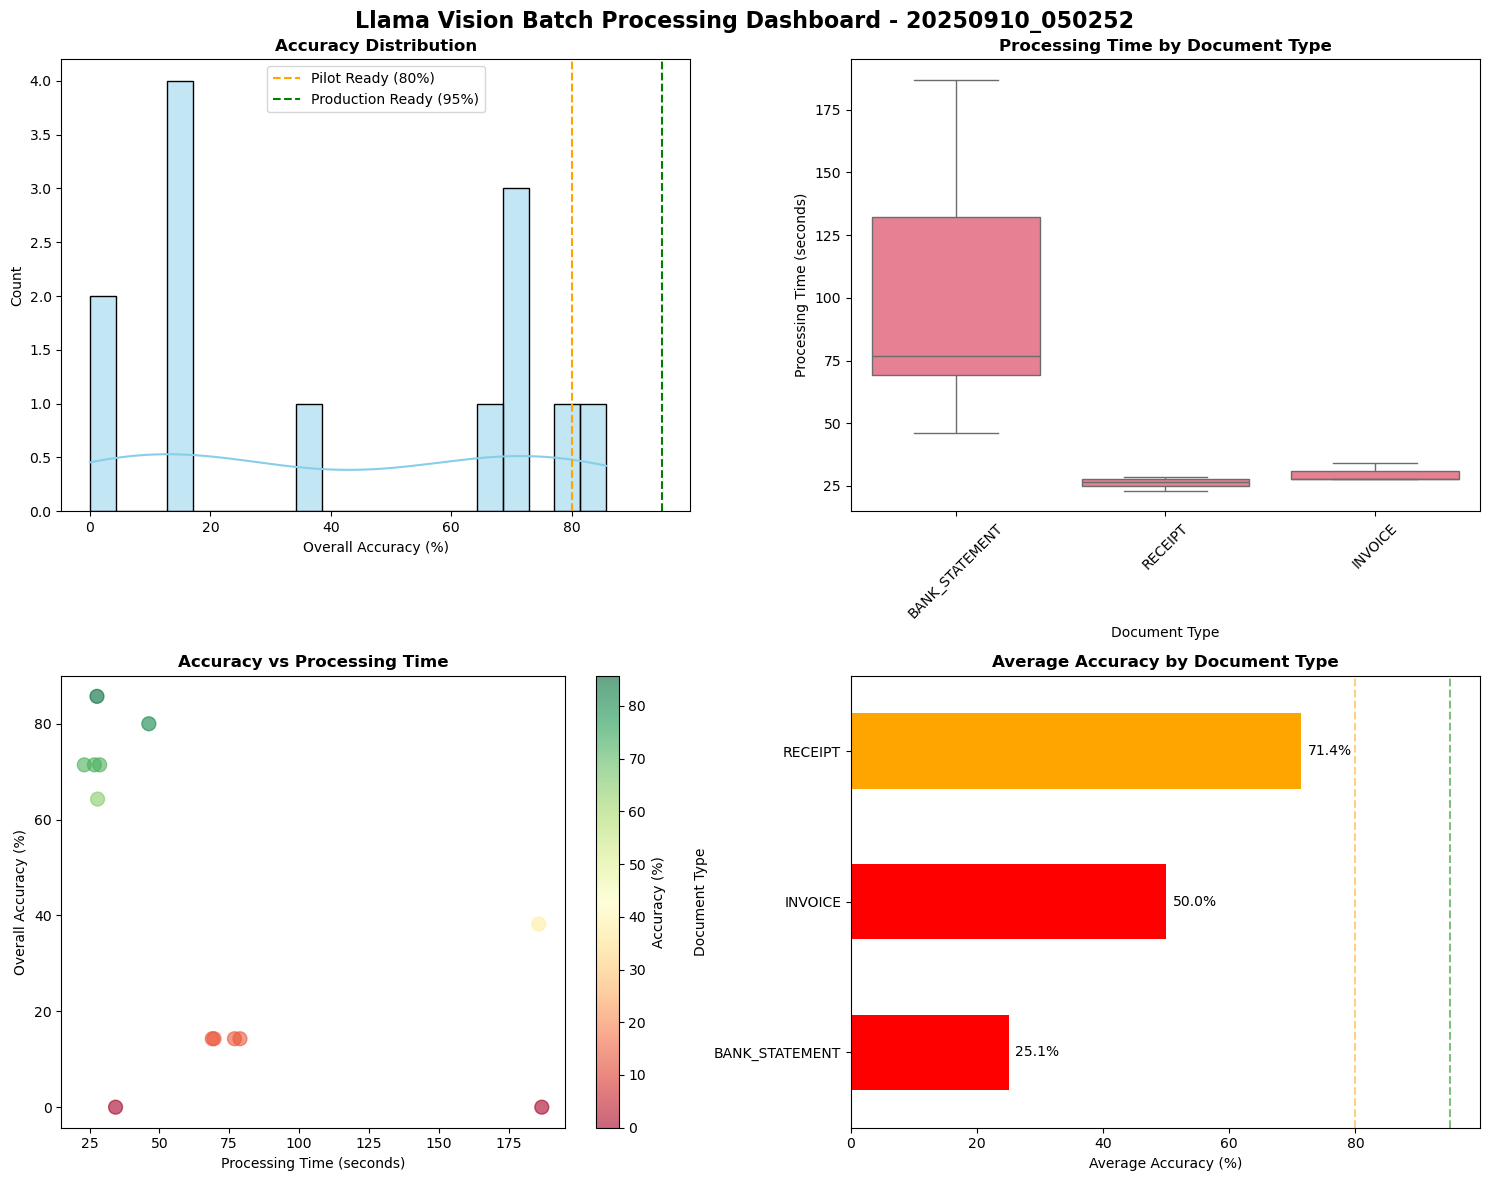

⚠️ No field-level accuracy data available

✅ Created 1 visualizations

In [8]:
# Create visualizations
visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    BATCH_TIMESTAMP,
    show=True  # Set to False for headless execution
)

rprint(f"[green]✅ Created {len(viz_files)} visualizations[/green]")

## 8. Generate Reports

In [9]:
# Generate reports
reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,
    BATCH_TIMESTAMP
)

# Save all reports
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'use_quantization': CONFIG['USE_QUANTIZATION'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE']
    },
    verbose=True
)

# Display executive summary
markdown_report = reporter.generate_executive_summary(
    df_results, df_doctype_stats, OUTPUT_DIRS['base']
)
display(Markdown(markdown_report))

✅ Executive summary saved to /home/jovyan/nfs_share/tod/LMM_POC/output/reports/batch_report_20250910_050252.md

✅ Complete results exported to 
/home/jovyan/nfs_share/tod/LMM_POC/output/batch_results/batch_results_20250910_050252.json

# Llama Vision Batch Processing Report

**Generated:** 2025-09-10 05:17:45  
**Batch ID:** 20250910_050252  
**Model:** Llama-3.2-11B-Vision-Instruct  

## Executive Summary

### Overall Performance
- **Total Images Processed:** 13
- **Successful Extractions:** 13 (100.0%)
- **Average Accuracy:** 41.51%
- **Deployment Status:** 🔴 **Needs Improvement**

### Processing Efficiency
- **Total Processing Time:** 881.48 seconds (14.7 minutes)
- **Average Time per Image:** 67.81 seconds
- **Throughput:** 0.9 images/minute

### Document Type Distribution
- **BANK_STATEMENT:** 7 (53.8%)
- **RECEIPT:** 3 (23.1%)
- **INVOICE:** 3 (23.1%)

### Accuracy by Document Type
- **BANK_STATEMENT:** 25.05%
- **INVOICE:** 50.00%
- **RECEIPT:** 71.43%

### Top Performing Images
- image_005.png: 85.7% (INVOICE)
- commbank_flat_simple.png: 80.0% (BANK_STATEMENT)
- image_001.png: 71.4% (RECEIPT)
- image_002.png: 71.4% (RECEIPT)
- image_004.png: 71.4% (RECEIPT)

### Areas for Improvement
- commbank_flat_complex_debit_credit.png: 0.0% (BANK_STATEMENT)
- image_006.png: 0.0% (INVOICE)
- anz_statement_001.png: 14.3% (BANK_STATEMENT)
- commbank_statement_001.png: 14.3% (BANK_STATEMENT)
- nab_statement_001.png: 14.3% (BANK_STATEMENT)

## Output Files Generated

All results have been saved to: `/home/jovyan/nfs_share/tod/LMM_POC/output`

- **CSV Files:** `csv/batch_20250910_050252_*.csv`
- **Visualizations:** `visualizations/*_20250910_050252.png`
- **Full Report:** `reports/batch_report_20250910_050252.md`

## Technical Details

- **V100 Optimizations:** Enabled (ResilientGenerator, Memory Cleanup)
- **Quantization:** 8-bit with BitsAndBytesConfig
- **Max Tokens:** 4000
- **Device:** CUDA (auto-mapped)


## 9. Final Summary

In [10]:
# Display final summary
console.rule("[bold green]Batch Processing Complete[/bold green]")

summary_table = Table(title="Final Summary")
summary_table.add_column("Metric", style="cyan")
summary_table.add_column("Value", style="green")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0
throughput = 60 / np.mean(processing_times) if processing_times else 0

summary_table.add_row("Total Images", str(total_images))
summary_table.add_row("Success Rate", f"{(successful/total_images*100):.1f}%")
summary_table.add_row("Average Accuracy", f"{avg_accuracy:.2f}%")
summary_table.add_row("Throughput", f"{throughput:.1f} img/min")
summary_table.add_row("Output Directory", str(OUTPUT_BASE))

console.print(summary_table)

rprint(f"\n[bold green]🎉 All results saved to: {OUTPUT_BASE}[/bold green]")
rprint(f"[cyan]📊 CSV files: {len(saved_files)} files[/cyan]")
rprint(f"[cyan]📈 Visualizations: {len(viz_files)} charts[/cyan]")
rprint(f"[cyan]📄 Reports: {len(report_files)} documents[/cyan]")

──────────────────────────────────────────── Batch Processing Complete ────────────────────────────────────────────

                         Final Summary                          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Metric           ┃ Value                                     ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Total Images     │ 13                                        │
│ Success Rate     │ 100.0%                                    │
│ Average Accuracy │ 41.51%                                    │
│ Throughput       │ 0.9 img/min                               │
│ Output Directory │ /home/jovyan/nfs_share/tod/LMM_POC/output │
└──────────────────┴───────────────────────────────────────────┘

🎉 All results saved to: /home/jovyan/nfs_share/tod/LMM_POC/output

📊 CSV files: 3 files

📈 Visualizations: 1 charts

📄 Reports: 2 documents